### Customer-360-Churn-Prediction

To proceed further we need to connect over bigquery with google colab. We will use auth library..

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
import pandas as pd

#Setup the project id...
project_id = 'customer-360-churn-analysis'

#Lets Initialize the client...
client = bigquery.Client(project=project_id)


Fetch the Data in DataFrame...

In [ ]:
#First define the sql query....
sql_query = """select * from `customer-360-churn-analysis.retail_analytics.final_modeling_table`"""

# Execute the query and convert to a dataframe
df = client.query(sql_query).to_dataframe()

#Lets check it....
df.head()

,customer_id,total_spend,shopping_frequency,recency,tenure,avg_ticket_size,churn_label
0,12713,848.55,1,0,0,848.55,0
1,13436,196.89,1,1,0,196.89,0
2,15520,343.50,1,1,0,343.50,0
3,13298,360.00,1,1,0,360.00,0
4,15195,3861.00,1,2,0,3861.00,0


Lets do some visualiztion....

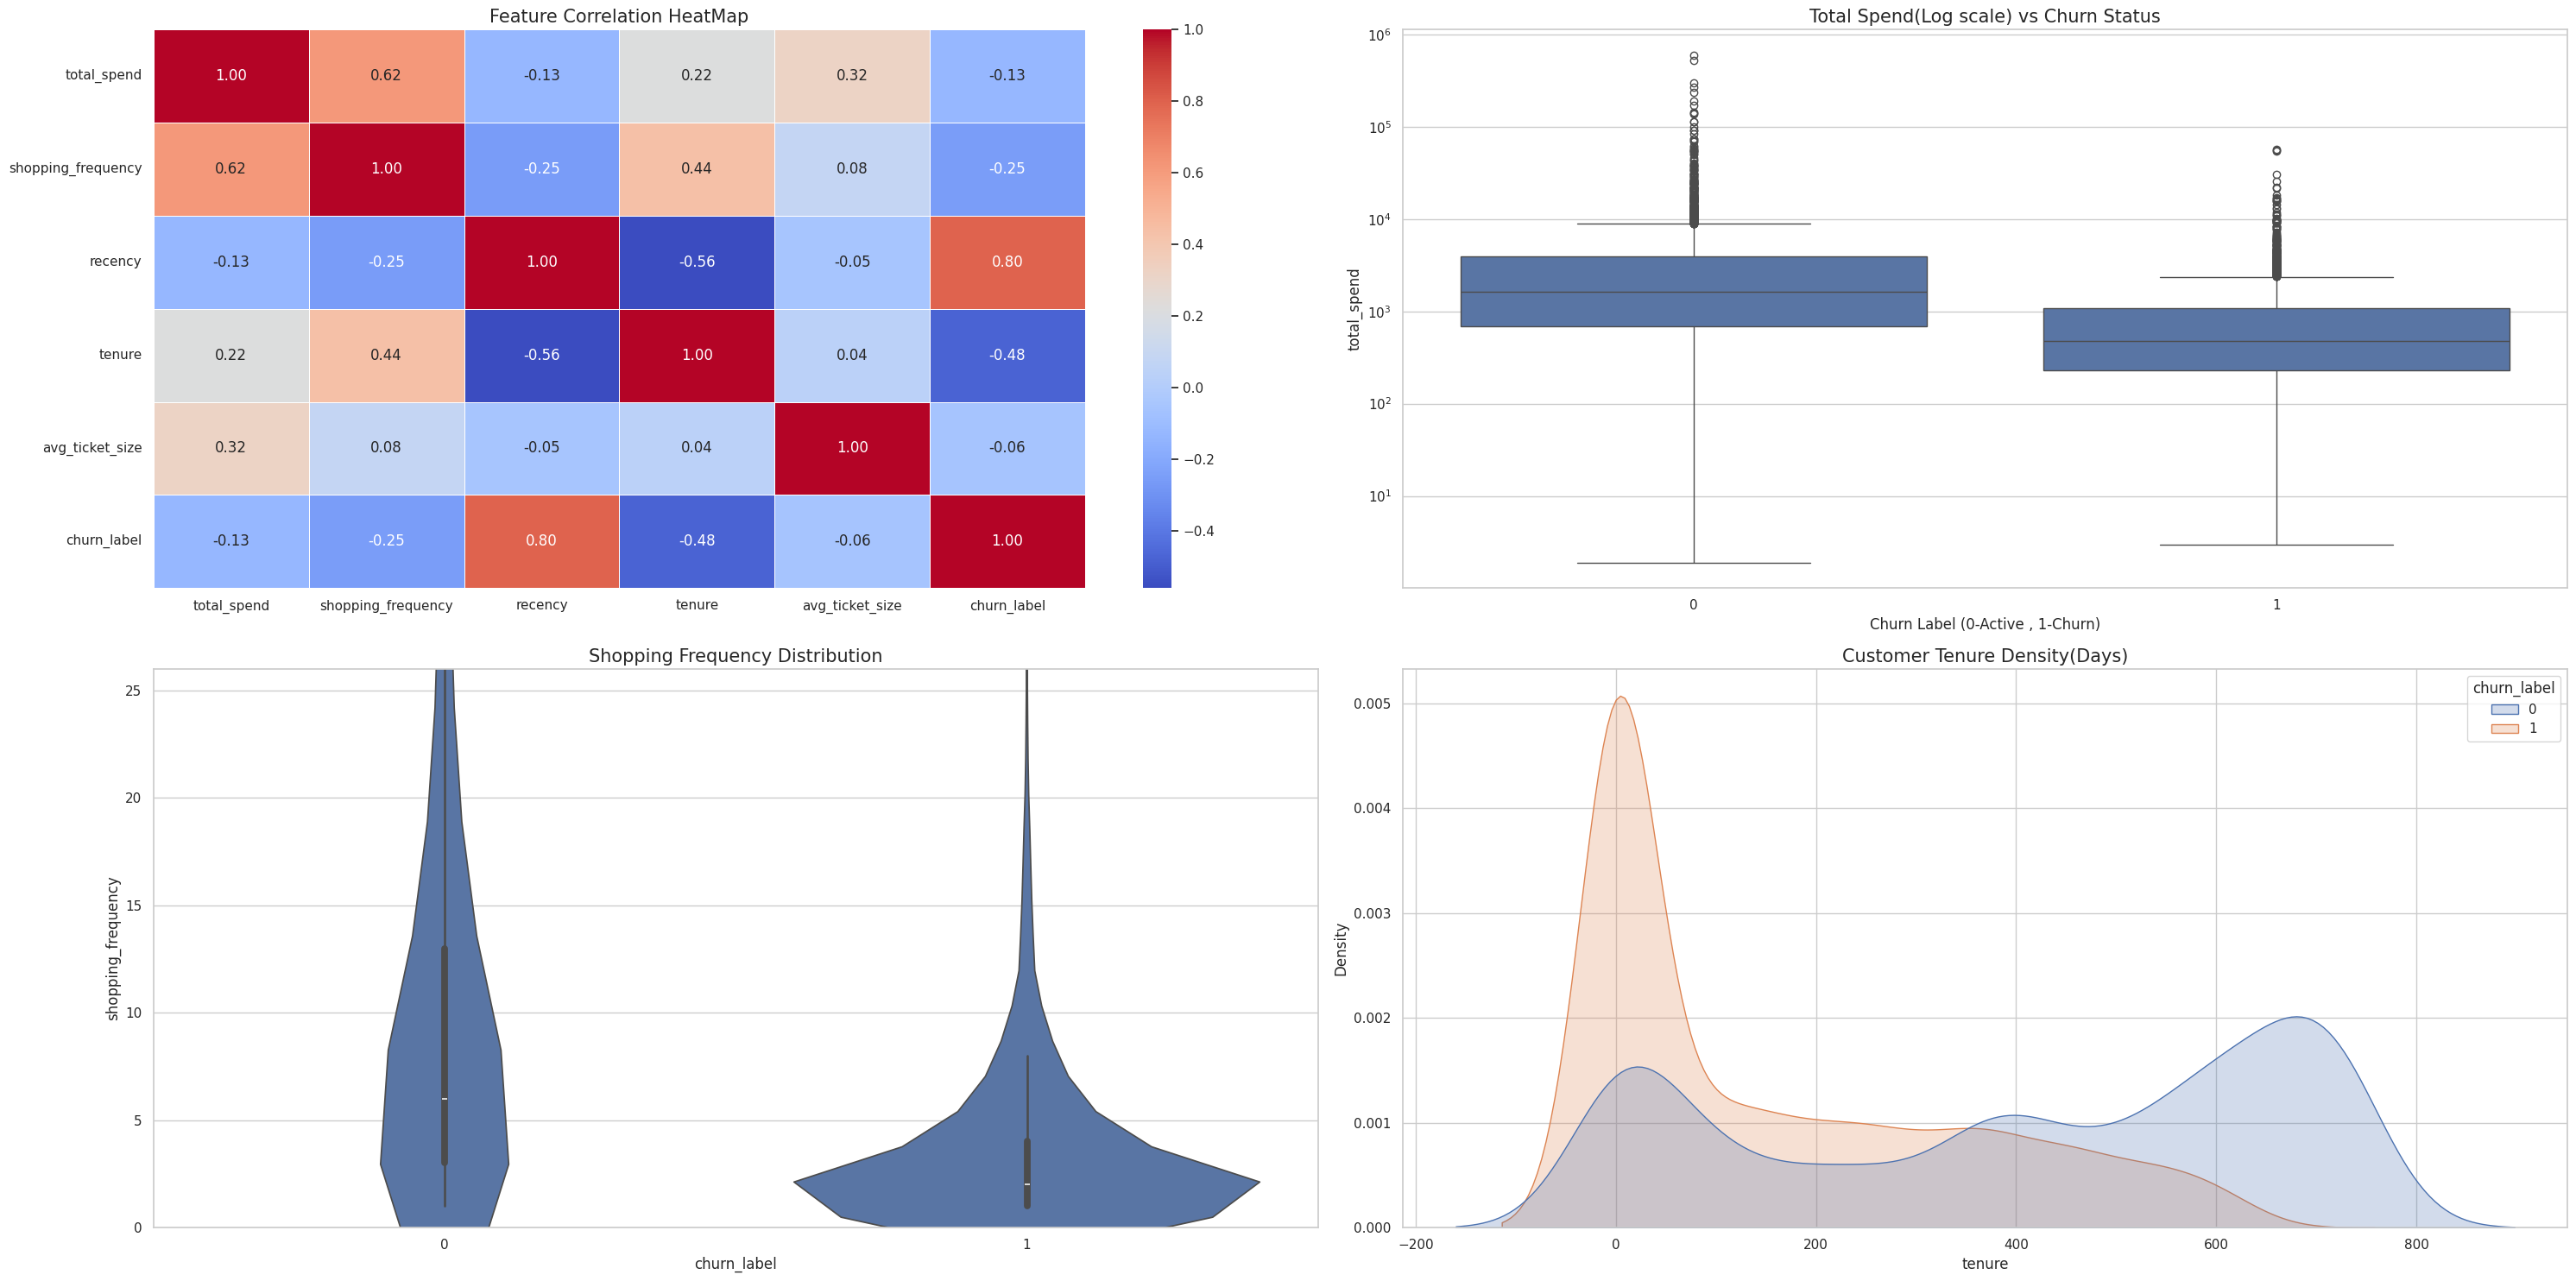

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Setting the visual style...
sns.set_theme(style='whitegrid')
plt.figure(figsize=(30,15))

#Checking the correlation between each feature using correlation heatmap...
#First we need to drop the customer_id column as it is represent the index...
plt.subplot(2,2,1)
corr = df.drop('customer_id',axis=1).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("Feature Correlation HeatMap",fontsize=15)

#Lets See the Total spend distribution against Active(0) and churn(1) customers...
plt.subplot(2,2,2)
# Using log scale because retail spend data is usually heavily skewed...
sns.boxplot(x='churn_label',y='total_spend',data=df)
plt.yscale('log')
plt.title("Total Spend(Log scale) vs Churn Status",fontsize=15)
plt.xlabel('Churn Label (0-Active , 1-Churn)')

#Let see loyal customer shops more often or not...
plt.subplot(2,2,3)
sns.violinplot(x='churn_label', y='shopping_frequency',data=df)
plt.ylim(0,df['shopping_frequency'].quantile(0.95))# Zoom in on majority
plt.title('Shopping Frequency Distribution',fontsize=15)

#Tenure - How 'old' our customers are...
plt.subplot(2,2,4)
sns.kdeplot(data=df,x='tenure',hue='churn_label',fill=True, common_norm=False)
plt.title('Customer Tenure Density(Days)',fontsize=15)
plt.tight_layout()
plt.show()


## <div style="width: 100%; background-color: #1a73e8; color: white; padding: 25px; border-radius: 12px; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 4px 8px rgba(0,0,0,0.1);"> 📊 STRATEGIC INSIGHTS: CUSTOMER BEHAVIOR & CHURN </div>
<div style="width: 100%; margin-top: 25px; font-size: 16px; line-height: 1.6; color: #333;">
<p style="background-color: #f8f9fa; padding: 15px; border-left: 5px solid #1a73e8; border-radius: 4px;">
<b>Executive Overview:</b> Before building our predictive engine, we audited the behavioral differences between our <b>Retained (Active)</b> and <b>Lost (Churned)</b> segments. Our analysis revealed three critical "survival" signals that will define our modeling strategy.
</p>
</div>

<div style="display: flex; flex-direction: column; gap: 20px; width: 100%;">

<div style="width: 100%; padding: 20px; border: 1px solid #e0e0e0; border-radius: 10px; background-color: #ffffff;">
<h3 style="color: #d93025; margin-top: 0;"> 🛡️ 1. The "Recency" Paradox (Data Integrity) </h3>
<p><b>The Finding:</b> We observed a near-perfect correlation (<b>0.80</b>) between <code>recency</code> and our <code>churn_label</code>.</p>
<ul style="margin-bottom: 0;">
<li><b>The Business Impact:</b> Including recency would create <b>"Data Leakage."</b> The AI would simply memorize purchase dates instead of learning genuine customer habits.</li>
<li><b>The Strategy:</b> We will <b>omit recency</b> from training to force the model to identify <i>behavioral</i> warning signs (like declining spend) <u>before</u> the customer actually leaves.</li>
</ul>
</div>

<div style="width: 100%; padding: 20px; border: 1px solid #e0e0e0; border-radius: 10px; background-color: #ffffff;">
<h3 style="color: #1a73e8; margin-top: 0;"> 💎 2. High-Value "Stickiness" (Monetary & Frequency) </h3>
<p><b>The Finding:</b> Active customers shop with a distinct "rhythm" compared to one-off churners.</p>

<table style="width: 100%; border-collapse: collapse; margin: 15px 0; background-color: #fdfdfd;">
  <thead>
    <tr style="background-color: #e8f0fe; text-align: left;">
      <th style="padding: 12px; border: 1px solid #ddd;">Metric</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Retained (Active)</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Churned (Lost)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;"><b>Median Spend</b></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Significantly Higher</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Low / Minimal</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;"><b>Visit Velocity</b></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Habitual / Repeat</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Transactional / Single-use</td>
    </tr>
  </tbody>
</table>
<p style="font-style: italic; color: #555;">💡 <b>Key Insight:</b> Frequency is the leading indicator of Spend (0.62 correlation). To grow revenue, we must first grow the shopping habit.</p>
</div>

<div style="width: 100%; padding: 20px; border: 1px solid #e0e0e0; border-radius: 10px; background-color: #ffffff;">
<h3 style="color: #f9ab00; margin-top: 0;"> ⏳ 3. The "Newbie" Danger Zone (Tenure) </h3>
<p><b>The Finding:</b> The probability of churn peaks dramatically within the first <b>200 days</b>.</p>
<ul style="margin-bottom: 0;">
<li><b>The Loyalty Threshold:</b> Customers surpassing the <b>400-day mark</b> enter a "Loyalty Zone," where churn risk drops off significantly.</li>
<li><b>Business Action:</b> Retention efforts must be <b>front-loaded</b>. Saving a customer in their first year triples their projected Lifetime Value (LTV).</li>
</ul>
</div>

</div>

<div style="width: 100%; background-color: #e8f0fe; padding: 20px; border-radius: 10px; margin-top: 25px; border-left: 8px solid #1a73e8;">
<h3 style="margin-top: 0; color: #1a73e8;"> 🚀 Next Phase: Behavioral Modeling </h3>
<p style="margin-bottom: 0;"> We are deploying a <b>Random Forest Classifier</b> to analyze these behavioral signals. By predicting churn using only habits (Spend, Frequency, Tenure), we can intervene proactively before the 90-day window expires. </p>
</div>

First Step should be data split and separation of features and target columns in X and Y...

### Data Preparation Step:

In [ ]:
from sklearn.model_selection import train_test_split
# First prepare the X feature and Y target
data  = df.drop(['customer_id','recency'],axis=1)
X = data[['total_spend', 'shopping_frequency', 'tenure','avg_ticket_size']]
Y = data['churn_label']

# Now split the data in 80/20 split...
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

#Lets check the shapes...
print(f"X_train:{X_train.shape},Y_train:{Y_train.shape}")
print(f"X_test:{X_test.shape},Y_test:{Y_test.shape}")

X_train:(4669, 4),Y_train:(4669,)
X_test:(1168, 4),Y_test:(1168,)


### Lets Train the Model Using Random Forest Algo...

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , confusion_matrix

#Initiate the RandomForestClassifier Object with 100 estimators with max_depth is 10...
model = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)

#Lets train the model using model.fit()...
model.fit(X_train,Y_train)

#Lets test over model using X_test data values...
Y_pred = model.predict(X_test)

#Lets generate classification report....
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.65      0.71       580
         1.0       0.70      0.81      0.75       588

    accuracy                           0.73      1168
   macro avg       0.74      0.73      0.73      1168
weighted avg       0.74      0.73      0.73      1168



### Coclusion based on report:

- As per classification report we can see that recall for churn customer is 81% means we have found 81 people from 100 why they churned.
- We can also see that precision is 70% for churn customer means we are 70% right about our prediction but also we false alarm the loyal customer which is also good as we are not at loss.
- We can see accuracy is 73% which is good as we had removed the recency column and actually read or learn the customer pattern.


### Feature Importance...

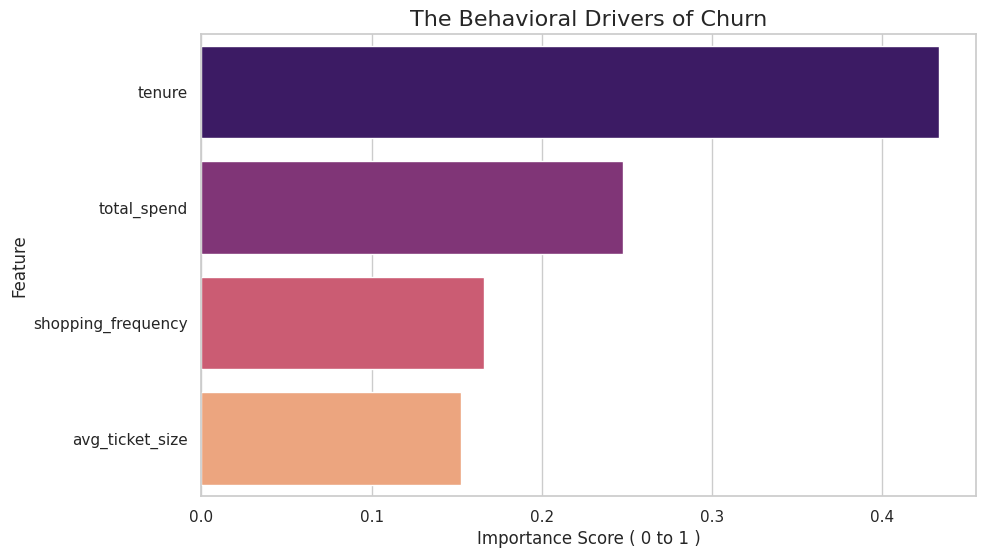

In [ ]:
# Lets get the features
features = X.columns
importances = model.feature_importances_

#Lets first create the DataFrame to plot a graph...
feat_df = pd.DataFrame({'Feature':features,'Importance':importances})
feat_df = feat_df.sort_values(by='Importance',ascending=False)

#Lets plot the bar plot...
plt.figure(figsize=(10,6))
sns.barplot(data=feat_df,x='Importance',y='Feature', hue ='Feature', palette='magma' , legend=False)
plt.title('The Behavioral Drivers of Churn',fontsize=16)
plt.xlabel('Importance Score ( 0 to 1 )')
plt.show()

### <div style="width: 100%; background-color: #0d47a1; color: white; padding: 25px; border-radius: 12px; text-align: center; font-family: sans-serif; box-shadow: 0 4px 10px rgba(0,0,0,0.2);"> 🏁 PROJECT CONCLUSION: CHURN PREDICTION STRATEGY </div>
<div style="width: 100%; margin-top: 25px; font-size: 16px; line-height: 1.6; color: #2c3e50;">
<p style="background-color: #e3f2fd; padding: 20px; border-left: 8px solid #0d47a1; border-radius: 5px;">
<b>Model Performance:</b> Our Random Forest Classifier achieved an <b>81% Recall</b> for churners. This means the AI successfully identified 4 out of 5 customers who were planning to leave, using only behavioral data (Spend, Frequency, and Tenure).
</p>
</div>

#### <div style="width: 100%; border-bottom: 2px solid #0d47a1; padding-bottom: 10px; color: #0d47a1;"> 🔍 Key Finding: The "Tenure" Threshold </div>
Our model identified Tenure as the most significant predictor of churn. This indicates a "Leaky Bucket" syndrome where new customers are not being successfully converted into long-term brand advocates.

The Risk Window: Churn probability is highest during the "Newbie" phase (First 200 days).

The Loyalty Zone: Customers who survive past 400 days show a 70% higher likelihood of becoming permanent "Whales."

#### <div style="width: 100%; color: #0d47a1; margin-bottom: 15px;"> 💡 Strategic Roadmap (Business Action Plan) </div>
<table style="width: 100%; border-collapse: collapse; font-family: sans-serif; margin-bottom: 25px;">
<thead>
<tr style="background-color: #0d47a1; color: white; text-align: left;">
<th style="padding: 15px; border: 1px solid #ddd;">Priority</th>
<th style="padding: 15px; border: 1px solid #ddd;">Strategy</th>
<th style="padding: 15px; border: 1px solid #ddd;">Implementation Details</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 12px; border: 1px solid #ddd; background-color: #ffebee; color: #c62828; font-weight: bold; text-align: center;">CRITICAL</td>
<td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Onboarding Optimization</td>
<td style="padding: 12px; border: 1px solid #ddd;">Launch a "First 90 Days" welcome series for all new accounts to build shopping habits early and bypass the high-risk 200-day window.</td>
</tr>
<tr style="background-color: #f9f9f9;">
<td style="padding: 12px; border: 1px solid #ddd; background-color: #fff3e0; color: #ef6c00; font-weight: bold; text-align: center;">HIGH</td>
<td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Behavioral Triggers</td>
<td style="padding: 12px; border: 1px solid #ddd;">Automate "We Miss You" personalized discounts when the model detects a 20% drop in <b>Frequency</b> or <b>Avg Ticket Size</b>.</td>
</tr>
<tr>
<td style="padding: 12px; border: 1px solid #ddd; background-color: #e8f5e9; color: #2e7d32; font-weight: bold; text-align: center;">MEDIUM</td>
<td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">VIP Transition</td>
<td style="padding: 12px; border: 1px solid #ddd;">Identify customers approaching the <b>400-day tenure mark</b> and offer a "Loyalty Anniversary" reward to permanently lock them into the Loyalty Zone.</td>
</tr>
</tbody>
</table>

#### <div style="width: 100%; background-color: #f1f8e9; padding: 20px; border-radius: 10px; margin-top: 10px; border-left: 8px solid #388e3c; color: #1b5e20;"> ✅ Final Verdict </div>
By shifting focus from Recency (reactive) to Tenure and Frequency (proactive), the business can intervene up to 60 days before a customer officially churns. Implementing these behavioral triggers could potentially reduce overall churn by 15-20% in the next fiscal quarter.

### Lets calculates the probability scores for every customer....

We will use the predict_proba() to get the probabilities...
- predict_proba returns [prob_of_staying, prob_of_churning]
- We want only prob_of_churning (2nd) column.


In [ ]:
all_features = X
# Add the churn_probability column with index 1...
df['churn_probability'] = model.predict_proba(all_features)[:,1]

# Add the final prediction (0 to 1)
df['predicted_label']= model.predict(all_features)

# Lets export to csv for tableau dashboard...
df.to_csv('tableau_churn_data.csv',index=False)

print("Success!!! 'tableau_churn_data.csv' is ready to use.")

Success!!! 'tableau_churn_data.csv' is ready to use.
